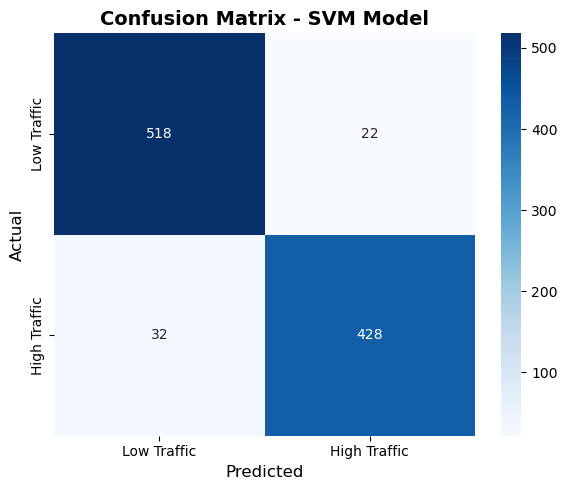

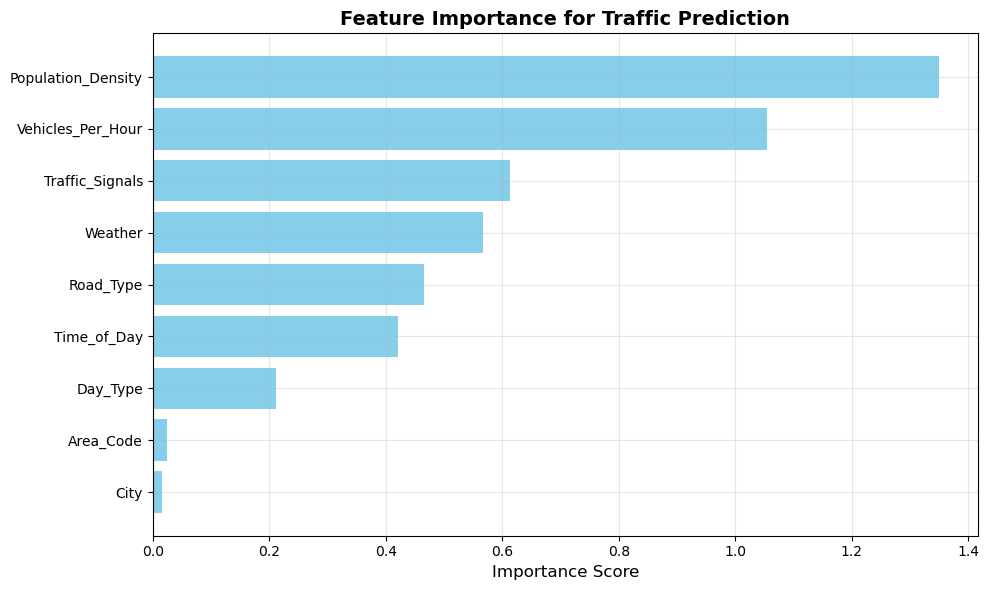

Accuracy: 0.9460

✅ Graphs saved: confusion_matrix.png and feature_importance.png


['traffic_features.pkl']

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Load and prepare data
df = pd.read_csv("traffic.csv")
X = df.drop('Traffic_High', axis=1)
y = df['Traffic_High']

for col in ['City', 'Weather', 'Time_of_Day', 'Day_Type', 'Road_Type']:
    X[col] = LabelEncoder().fit_transform(X[col])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = SVC(kernel='rbf')
model.fit(X_train, y_train)
predictions = model.predict(X_test)

# ============================================
# GRAPH 1: Confusion Matrix
# ============================================
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low Traffic', 'High Traffic'],
            yticklabels=['Low Traffic', 'High Traffic'])
plt.title('Confusion Matrix - SVM Model', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()

# ============================================
# GRAPH 2: Feature Importance
# ============================================
linear_model = SVC(kernel='linear')
linear_model.fit(X_train, y_train)

feature_names = ['City', 'Area_Code', 'Population_Density', 'Vehicles_Per_Hour', 
                 'Traffic_Signals', 'Weather', 'Time_of_Day', 'Day_Type', 'Road_Type']

importance = abs(linear_model.coef_[0])
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feature_importance = feature_importance.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='skyblue')
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance for Traffic Prediction', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100)
plt.show()

print(f"Accuracy: {model.score(X_test, y_test):.4f}")
print("\n✅ Graphs saved: confusion_matrix.png and feature_importance.png")

import joblib

# ============================================
# SAVE MODEL AND PREPROCESSORS FOR BACKEND
# ============================================

# Model save karo
joblib.dump(model, 'traffic_model.pkl')

# StandardScaler save karo (important for scaling input data)
joblib.dump(scaler, 'traffic_scaler.pkl')

# Feature names save karo (for reference)
feature_names_list = ['City', 'Area_Code', 'Population_Density', 'Vehicles_Per_Hour', 
                      'Traffic_Signals', 'Weather', 'Time_of_Day', 'Day_Type', 'Road_Type']
joblib.dump(feature_names_list, 'traffic_features.pkl')

In [3]:
# Check class distribution in training data
print("="*50)
print("TRAFFIC DATA CLASS DISTRIBUTION")
print("="*50)
print(df['Traffic_High'].value_counts())
print(f"\nPercentage of High Traffic: {df['Traffic_High'].mean()*100:.2f}%")
print(f"Percentage of Low Traffic: {(1-df['Traffic_High'].mean())*100:.2f}%")

TRAFFIC DATA CLASS DISTRIBUTION
Traffic_High
0    2750
1    2250
Name: count, dtype: int64

Percentage of High Traffic: 45.00%
Percentage of Low Traffic: 55.00%
